In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# 🌍 ImpactSense - Earthquake Impact Prediction  
## Week 1: Exploratory Data Analysis (EDA)

Load dataset  <----

In [2]:
data = pd.read_csv("Earthquakes_Dataset.csv")
data.head()

,place,mag,magType,type,time,longitude,latitude,depth_km,sig,net,nst,dmin,rms,gap
0,"113 km W of Petrolia, CA",2.56,md,earthquake,2025-02-11 14:34:38.190,-125.614334,40.216499,4.95,101,nc,14.0,0.97600,0.12,325.0
1,"9 km N of Taft, CA",1.54,ml,earthquake,2025-02-11 14:28:19.490,-119.456833,35.225167,18.24,36,ci,31.0,0.08479,0.20,116.0
2,"58 km WNW of Petrolia, CA",2.84,md,earthquake,2025-02-11 14:24:27.270,-124.964500,40.401165,4.20,124,nc,30.0,0.48850,0.37,274.0
3,"24 km NNW of Searles Valley, CA",1.49,ml,earthquake,2025-02-11 14:24:22.730,-117.515663,35.967335,4.01,34,ci,19.0,0.11100,0.16,83.0
4,"12 km WNW of Anza, CA",0.56,ml,earthquake,2025-02-11 14:12:30.720,-116.803167,33.584500,8.69,5,ci,25.0,0.05820,0.16,69.0


----->  Dataset information 

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22738 entries, 0 to 22737
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   place      22738 non-null  object 
 1   mag        22738 non-null  float64
 2   magType    22738 non-null  object 
 3   type       22738 non-null  object 
 4   time       22738 non-null  object 
 5   longitude  22738 non-null  float64
 6   latitude   22738 non-null  float64
 7   depth_km   22738 non-null  float64
 8   sig        22738 non-null  int64  
 9   net        22738 non-null  object 
 10  nst        22738 non-null  float64
 11  dmin       22738 non-null  float64
 12  rms        22738 non-null  float64
 13  gap        22738 non-null  float64
dtypes: float64(8), int64(1), object(5)
memory usage: 2.4+ MB


-----> Summary statistics

In [4]:
data.describe()

,mag,longitude,latitude,depth_km,sig,nst,dmin,rms,gap
count,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000,22738.000000
mean,1.481742,-100.489911,36.216841,15.467917,67.213827,24.452458,0.487572,0.216859,111.526936
std,1.468251,69.446986,17.141390,53.243223,109.585431,22.927217,1.823934,0.264214,63.769321
min,-1.890000,-179.964000,-73.220400,-3.460000,0.000000,3.000000,0.000000,0.000000,14.000000
25%,0.600000,-122.821831,33.506333,2.270000,6.000000,9.000000,0.013820,0.060000,65.000000
50%,1.110000,-119.039833,38.492850,6.245400,19.000000,17.000000,0.052585,0.130000,91.000000
75%,1.910000,-110.815375,40.354167,10.000000,56.750000,31.000000,0.125000,0.210000,146.000000
max,7.600000,179.971600,82.479300,690.121000,1177.000000,242.000000,29.638000,1.720000,348.000000


-------->  Data type check

In [5]:
print("Data Types:")
data.dtypes

Data Types:


place         object
mag          float64
magType       object
type          object
time          object
longitude    float64
latitude     float64
depth_km     float64
sig            int64
net           object
nst          float64
dmin         float64
rms          float64
gap          float64
dtype: object

------>  Data type correction

In [6]:
data['time'] = pd.to_datetime(data['time'], errors='coerce')

print("Updated Data Types:")
data.dtypes

Updated Data Types:


place                object
mag                 float64
magType              object
type                 object
time         datetime64[ns]
longitude           float64
latitude            float64
depth_km            float64
sig                   int64
net                  object
nst                 float64
dmin                float64
rms                 float64
gap                 float64
dtype: object

-------->  Missing values

In [7]:
print("Missing Values in Each Column:")
data.isnull().sum()

Missing Values in Each Column:


place          0
mag            0
magType        0
type           0
time         138
longitude      0
latitude       0
depth_km       0
sig            0
net            0
nst            0
dmin           0
rms            0
gap            0
dtype: int64

----->  Duplicate removal

In [8]:
print("Shape before removing duplicates:", data.shape)

data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Shape before removing duplicates: (22738, 14)
Shape after removing duplicates: (8810, 14)


---->  Magnitude distribution

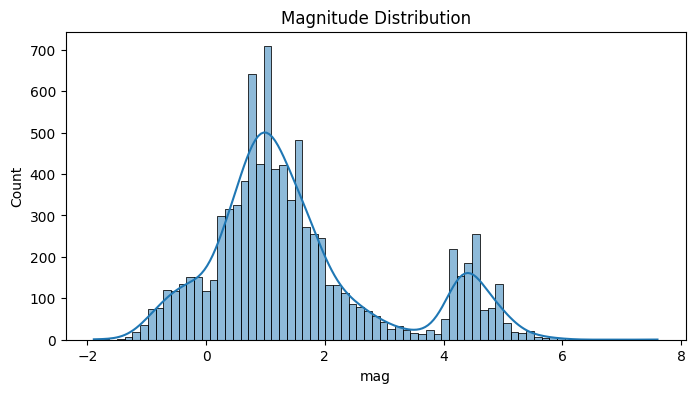

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(data['mag'], kde=True)
plt.title("Magnitude Distribution")
plt.show()

----->  Depth distribution

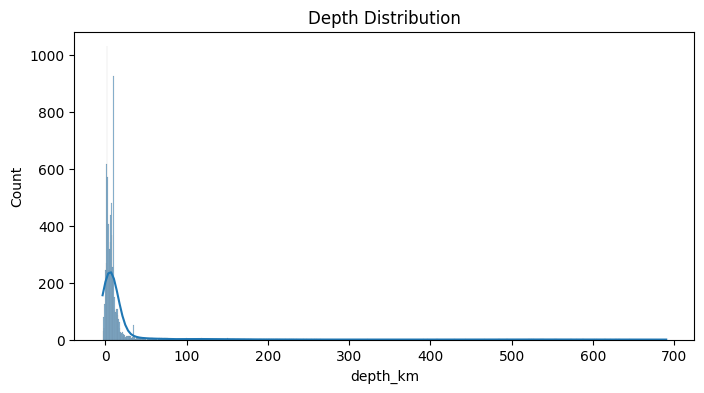

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(data['depth_km'], kde=True)
plt.title("Depth Distribution")
plt.show()

-------->  Outlier detection

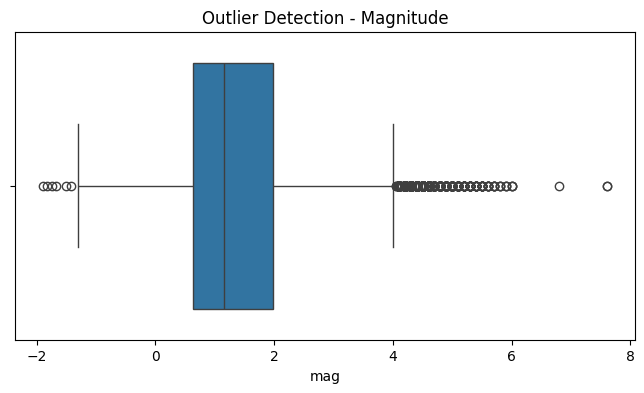

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=data['mag'])
plt.title("Outlier Detection - Magnitude")
plt.show()

---------->   Earthquake map

In [12]:
map_eq = folium.Map(
    location=[data['latitude'].mean(), data['longitude'].mean()],
    zoom_start=2
)

for i in range(min(300, len(data))):
    folium.CircleMarker(
        location=[data.iloc[i]['latitude'], data.iloc[i]['longitude']],
        radius=3,
        color='red',
        fill=True
    ).add_to(map_eq)

map_eq